# 🛡️ Dilithium 부채널 공격: 딥러닝 프로파일링 통합 가이드 (v4)

이 노트북은 DSCAD 데이터셋의 160,000개 프로파일링 트레이스와 10,000개 공격 트레이스를 활용하여 CRYSTALS-Dilithium의 부채널 취약점을 분석합니다.

## 🛠️ 주요 수정 사항
1. **함수명 정합성**: `extract_and_merge` 함수 정의와 호출명을 일치시켰습니다.
2. **차원 정합성 보장**: 4개의 데이터 세트(각 4만 개)를 하나의 16만 개 행렬로 정확히 통합하여 `IndexError`를 방지합니다.
3. **메모리 최적화**: `mmap_mode`와 슬라이싱을 사용하여 대용량 데이터를 효율적으로 처리합니다.
4. **클래스 불균형 해결**: `Class Weight`를 적용하여 데이터가 적은 HW 클래스에 대한 학습력을 높였습니다.
5. **상세 설명**: 각 단계별 목적과 동작 방식을 상세히 기술했습니다.

## 1. 초기화 및 환경 설정
필요한 라이브러리를 로드하고 데이터 및 모델 저장 경로를 설정합니다.

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# 경로 설정
DATASET_DIR = './Dataset'
RHO_PATH = './Pearson correlation coefficient/rho.npy'
MODELS_DIR = './models'
PROCESSED_X = 'x_train_160k_poi.npy'
PROCESSED_Y = 'y_train_160k_hw.npy'
PROCESSED_ATK_X = 'x_attack_10k_poi.npy'
PROCESSED_ATK_Y = 'y_attack_10k_hw.npy'

if not os.path.exists(MODELS_DIR): os.makedirs(MODELS_DIR)

def get_hw(n):
    """정수의 Hamming Weight를 계산합니다."""
    return bin(int(n) & 0xffffffff).count('1')

print("✅ 환경 설정 및 유틸리티 함수 로드 완료")

✅ 환경 설정 및 유틸리티 함수 로드 완료


## 2. 정보 누설 지점(POI) 분석
Pearson 상관계수(`rho.npy`)를 분석하여 전력 파형 중 비밀 정보 누설이 가장 큰 지점과 그 주변 영역을 추출합니다.

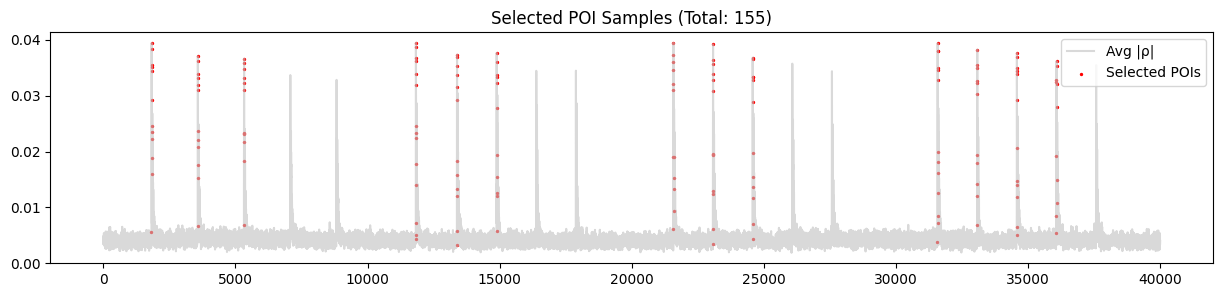

🎯 선정된 POI 샘플 수: 155


In [71]:
# 상관계수 데이터 로드 (L=4, 계수=256 등에 대한 분석 결과)
rho = np.load(RHO_PATH)
avg_abs_rho = np.mean(np.abs(rho), axis=0)

# 상위 누설 지점 주변 윈도우 추출 (25개 피크 주변 ±5 샘플)
num_peaks = 25
top_indices = np.argsort(avg_abs_rho)[-num_peaks:]
poi_window = []
for idx in top_indices:
    poi_window.extend(range(max(0, idx-5), min(40000, idx+6)))

pois = np.sort(np.unique(poi_window))

# 시각화
plt.figure(figsize=(15, 3))
plt.plot(avg_abs_rho, color='silver', alpha=0.6, label='Avg |ρ|')
plt.scatter(pois, avg_abs_rho[pois], color='red', s=2, label='Selected POIs')
plt.title(f"Selected POI Samples (Total: {len(pois)})")
plt.legend()
plt.show()

print(f"🎯 선정된 POI 샘플 수: {len(pois)}")

## 3. 데이터 전처리 파이프라인
4개의 프로파일링 데이터 파일(총 16만 개)을 하나로 통합하고, Z-score 정규화를 수행합니다.

In [72]:
def extract_and_merge(trace_files, pois, out_x_path, out_y_path, label_file, is_profiling=True):
    """
    여러 트레이스 파일을 하나로 통합하고 POI 추출 및 정규화를 수행합니다.
    """
    if os.path.exists(out_x_path) and os.path.exists(out_y_path):
        x_data = np.load(out_x_path)
        y_data = np.load(out_y_path)
        if x_data.shape[0] == y_data.shape[0]:
            print(f"♻️ 기존 통합 데이터 로드 완료: {x_data.shape}")
            return x_data, y_data
    
    print(f"🚀 데이터 통합 및 전처리 시작 (대상: {out_x_path})")
    
    # 레이블 데이터 준비
    labels_raw = np.load(label_file)
    u_values = labels_raw[:, 0, 50] # 공격 타겟: L=0, PolyIdx=50
    hw_values = np.array([get_hw(v) for v in u_values], dtype=np.uint8)
    
    if is_profiling:
        y_hw = np.tile(hw_values, 4) # 4만 개 레이블을 4번 반복 (16만 개)
    else:
        y_hw = hw_values
    
    total_samples = len(y_hw)
    final_x = np.zeros((total_samples, len(pois)), dtype=np.float32)
    
    curr_pos = 0
    for f_name in trace_files:
        traces = np.load(os.path.join(DATASET_DIR, f_name), mmap_mode='r')
        num_traces = len(traces)
        
        for i in tqdm(range(num_traces), desc=f_name):
            p_trace = traces[i, pois].astype(np.float32)
            # Z-score Normalization
            mean, std = np.mean(p_trace), np.std(p_trace)
            final_x[curr_pos] = (p_trace - mean) / (std if std > 1e-7 else 1.0)
            curr_pos += 1
            
    np.save(out_x_path, final_x)
    np.save(out_y_path, y_hw)
    return final_x, y_hw

profiling_trace_files = [
    'profiling_40000traces_set1.npy', 'profiling_40000traces_set2.npy', 
    'profiling_40000traces_set3.npy', 'profiling_40000traces_set4.npy'
]
attack_trace_files = ['attack_10000traces.npy']

# 전처리 실행
x_train_raw, y_train_raw = extract_and_merge(
    profiling_trace_files, pois, PROCESSED_X, PROCESSED_Y, 
    os.path.join(DATASET_DIR, 'profiling_40000_u=cs.npy'), True
)
x_attack_raw, y_attack_raw = extract_and_merge(
    attack_trace_files, pois, PROCESSED_ATK_X, PROCESSED_ATK_Y, 
    os.path.join(DATASET_DIR, 'attack_10000_u=cs.npy'), False
)

print(f"✅ 데이터 정합성 확인: X={x_train_raw.shape}, Y={y_train_raw.shape}")

🚀 데이터 통합 및 전처리 시작 (대상: x_train_160k_poi.npy)


profiling_40000traces_set4.npy: 100%|██████████| 10000/10000 [00:18<00:00, 552.14it/s]


🚀 데이터 통합 및 전처리 시작 (대상: x_attack_10k_poi.npy)


attack_10000traces.npy: 100%|██████████| 10000/10000 [00:18<00:00, 553.99it/s]

✅ 데이터 정합성 확인: X=(160000, 155), Y=(160000,)


## 4. 학습 데이터 정제 및 클래스 가중치 설정
샘플 수가 너무 적은 클래스를 제거하고, 클래스 불균형을 해결하기 위해 가중치를 계산합니다.

In [73]:
# 최소 샘플 수 기준 필터링 (안정적인 분할을 위해 150개 이상만 유지)
unique, counts = np.unique(y_train_raw, return_counts=True)
valid_classes = unique[counts >= 150]

mask = np.isin(y_train_raw, valid_classes)
x_clean = x_train_raw[mask]
y_clean = y_train_raw[mask]

print(f"⚠️ {len(unique) - len(valid_classes)}개 희소 클래스 제거됨. 유효 클래스: {valid_classes}")

# 클래스 불균형 보정을 위한 가중치 계산
class_weights = compute_class_weight('balanced', classes=np.unique(y_clean), y=y_clean)
cw_dict = {cls: weight for cls, weight in zip(np.unique(y_clean), class_weights)}

# 레이블 원-핫 인코딩
y_onehot = to_categorical(y_clean, num_classes=33)

# Train/Validation Split (8.5:1.5)
x_train, x_val, y_train, y_val = train_test_split(
    x_clean, y_onehot, test_size=0.15, random_state=42, stratify=y_clean
)

print(f"📊 학습 데이터: {x_train.shape}, 검증 데이터: {x_val.shape}")

⚠️ 6개 희소 클래스 제거됨. 유효 클래스: [ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27]
📊 학습 데이터: (135707, 155), 검증 데이터: (23949, 155)


## 5. 1D-CNN 모델 구축 및 학습
부채널 데이터의 특징을 학습하기 위한 최적화된 CNN 아키텍처를 정의하고 학습을 시작합니다.

In [74]:
def build_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim, 1)),
        Conv1D(64, kernel_size=7, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dense(33, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model(x_train.shape[1])
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    ModelCheckpoint(os.path.join(MODELS_DIR, 'dilithium_cnn_v4.keras'), save_best_only=True)
]

print("📺 모델 학습 시작...")
history = model.fit(
    x_train.reshape(-1, x_train.shape[1], 1), y_train,
    validation_data=(x_val.reshape(-1, x_val.shape[1], 1), y_val),
    epochs=70,
    batch_size=256,
    class_weight=cw_dict,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 155, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 155, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 77, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 77, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 77, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4864)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,490,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 33)             │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,656,673 (10.13 MB)

 Trainable params: 2,656,289 (10.13 MB)

 Non-trainable params: 384 (1.50 KB)

📺 모델 학습 시작...
Epoch 1/70
531/531 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.0442 - loss: 3.3941 - val_accuracy: 0.0746 - val_loss: 3.1505 - learning_rate: 0.0010
Epoch 2/70
531/531 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.0508 - loss: 2.9846 - val_accuracy: 0.0356 - val_loss: 3.0217 - learning_rate: 0.0010
Epoch 3/70
531/531 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.0538 - loss: 2.9638 - val_accuracy: 0.0476 - val_loss: 2.9578 - learning_rate: 0.0010
Epoch 4/70
531/531 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.0632 - loss: 2.9217 - val_accuracy: 0.0398 - val_loss: 2.9502 - learning_rate: 0.0010
Epoch 5/70
531/531 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.0631 - loss: 2.8706 - val_accuracy: 0.0448 - val_loss: 3.0360 - learning_rate: 0.0010
Epoch 6/70
531/531 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.0589 - loss: 2.8857 - val_accuracy: 0.0405 - val_loss: 3.0417 - learning_rate: 0.0010
Epoch 7/70
531/531 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accura

## 6. 공격 성능 분석 (Guessing Entropy)
공격용 트레이스를 사용하여 실제 비밀키(HW)를 얼마나 빨리 복구하는지 측정합니다.

🔍 Guessing Entropy 분석 중...


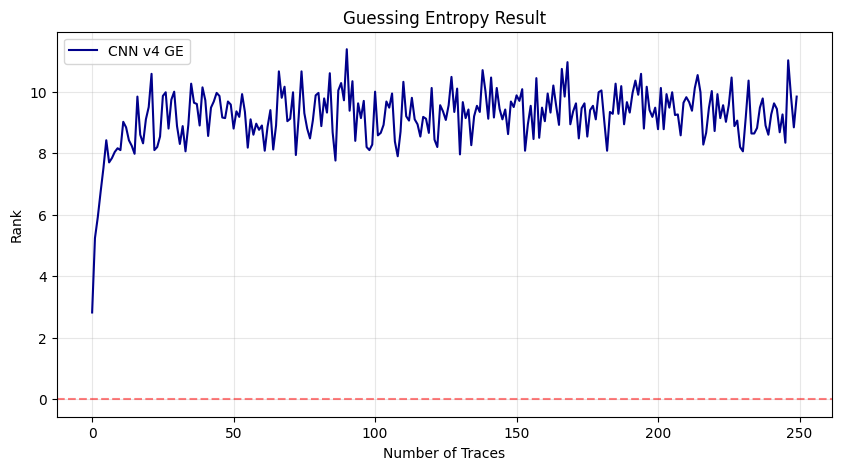

In [75]:
def evaluate_ge_attack(model, x_atk_raw, y_atk_hw, num_exp=50, max_traces=250):
    print("🔍 Guessing Entropy 분석 중...")
    preds = model.predict(x_atk_raw.reshape(-1, x_atk_raw.shape[1], 1), verbose=0)
    
    ge_all = []
    for _ in range(num_exp):
        indices = np.random.choice(len(x_atk_raw), max_traces, replace=False)
        log_probs = np.zeros(33)
        ranks = []
        
        for idx in indices:
            log_probs += np.log(preds[idx] + 1e-12)
            correct_hw = int(y_atk_hw[idx])
            
            # 확률 순위 계산
            ranking = np.argsort(log_probs)[::-1]
            rank = np.where(ranking == correct_hw)[0][0]
            ranks.append(rank)
        ge_all.append(ranks)
        
    avg_ge = np.mean(ge_all, axis=0)
    
    plt.figure(figsize=(10, 5))
    plt.plot(avg_ge, color='darkblue', label='CNN v4 GE')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.title("Guessing Entropy Result")
    plt.xlabel("Number of Traces"), plt.ylabel("Rank")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

evaluate_ge_attack(model, x_attack_raw, y_attack_raw)